In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import t as t_dist, norm
from scipy.linalg import cholesky
from pathlib import Path
import pickle
import time
import warnings
warnings.filterwarnings("ignore")

# MONTE CARLO SIMULATION — Raw Copula Innovations

These raw innovations are the stochastic shocks BEFORE any AR/ARMA
propagation or deterministic mean reconstruction. They are
scenario-agnostic.

Goal: Simulate N_SIM paths of correlated daily innovations
      (ε_CR, ε_KT, ε_temp) for the period 2026-01-01 to 2050-12-31
      using the fitted  copula and its Cholesky decomposition.

In [3]:
# ── paths ─────────────────────────────────────────────────────────────────────
copula_path   = Path("../../Code/Models/Copula")
models_path   = Path("../../Code/Models")
data_modelled = Path("../../Data/Modelled")
data_sim      = Path("../../Data/Simulated")
data_sim.mkdir(parents=True, exist_ok=True)

In [4]:
# ── simulation constants ──────────────────────────────────────────────────────
N_SIM        = 1000              # number of Monte Carlo paths
START_DATE   = "2026-01-01"
END_DATE     = "2050-12-31"
RANDOM_SEED  = 42

In [5]:
# variable order — must match copula estimation order
VAR_LABELS   = ["CR", "KT", "Temp"]
VAR_COLS     = ["eps_cr", "eps_kt", "eps_temp"]
 
print("── Step 0.1: Configuration ──────────────────────────────────────")
print(f"  N_SIM      : {N_SIM:,} paths")
print(f"  Horizon    : {START_DATE} → {END_DATE}")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Variables  : {VAR_LABELS}")
print(f"  Output     : {data_sim}")

── Step 0.1: Configuration ──────────────────────────────────────
  N_SIM      : 1,000 paths
  Horizon    : 2026-01-01 → 2050-12-31
  Random seed: 42
  Variables  : ['CR', 'KT', 'Temp']
  Output     : ..\..\Data\Simulated


## Load copula parameters

In [6]:

# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 0.2: Load copula parameters ────────────────────────────")

# ── copula ────────────────────────────────────────────────────────────────────
with open(copula_path / "copula_params.pkl", "rb") as f:
    copula_params = pickle.load(f)
 
nu_copula   = int(copula_params["nu"])
corr_matrix = np.array(copula_params["corr_matrix"])
chol_matrix = np.array(copula_params["chol_matrix"])
 
print(f"  Copula     : {copula_params['copula_type'].upper()}  ν={nu_copula}")
print(f"  Variables  : {copula_params['variables']}")
print(f"  n_obs fit  : {copula_params['n_obs']}")




── Step 0.2: Load copula parameters ────────────────────────────
  Copula     : T  ν=31
  Variables  : ['U_cr', 'U_kt', 'U_temp']
  n_obs fit  : 3073


In [7]:
# ── marginal scale parameters ─────────────────────────────────────────────────
with open(models_path / "Capture rate" / "cr_ar_params.pkl", "rb") as f:
    cr_params = pickle.load(f)

nu_g         = float(cr_params["nu_g"])
eta_g        = float(cr_params["eta_g"])   # skewness parameter
scale_unit_cr = np.sqrt(nu_g / (nu_g - 2))   # unit-variance skewed-t

print(f"  CR marginal  : skewed-t(ν={nu_g:.2f})  scale_unit={scale_unit_cr:.5f}  (GARCH-standardised z_t)")

# load all remaining marginals from covariance notebook output
with open(copula_path / "marginal_params.pkl", "rb") as f:
    marginal_params = pickle.load(f)

# KT: Gaussian
sigma_kt = float(marginal_params["sigma_kt"])
nu_kt    = int(marginal_params["nu_kt"])        # 0 = Gaussian
print(f"  KT marginal  : Gaussian  σ={sigma_kt:.5f}")

# Temp: t(ν_temp)
nu_temp    = float(marginal_params["nu_temp"])
scale_temp = float(marginal_params["scale_temp"])
sigma_temp = float(marginal_params["sigma_temp"])  # raw std for reference
print(f"  Temp marginal: t(ν={nu_temp:.2f})  "
      f"scale_t={scale_temp:.5f}  σ_raw={sigma_temp:.5f}")


# ── scale array — one entry per copula variable in order [CR, KT, Temp] ───────
# used only for display — Step 1 uses individual variables
scales = np.array([scale_unit_cr, sigma_kt, scale_temp])
print(f"\n  Scale array [CR, KT, Temp]: {np.round(scales, 5)}")

  CR marginal  : skewed-t(ν=4.23)  scale_unit=1.37722  (GARCH-standardised z_t)
  KT marginal  : Gaussian  σ=2.33721
  Temp marginal: t(ν=8.02)  scale_t=0.86725  σ_raw=1.00104

  Scale array [CR, KT, Temp]: [1.37722 2.33721 0.86725]


In [8]:
# verify Cholesky reconstruction
recon_err = np.max(np.abs(chol_matrix @ chol_matrix.T - corr_matrix))
print(f"\n  Reconstruction error: {recon_err:.2e}  "
      f"{'✓' if recon_err < 1e-10 else '✗ check chol_matrix'}")


  Reconstruction error: 1.11e-16  ✓


In [9]:
# STEP 0.3 — Build simulation calendar
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 0.3: Simulation calendar ───────────────────────────────")
 
dates_sim = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
N_DAYS    = len(dates_sim)
 
df_calendar = pd.DataFrame({
    "date":        dates_sim,
    "year":        dates_sim.year,
    "month":       dates_sim.month,
    "day":         dates_sim.day,
    "doy":         dates_sim.dayofyear,
    "weekday":     dates_sim.weekday,
    "decimal_year":(dates_sim.year + (dates_sim.dayofyear - 1) / 365.0),
    "t_year":      (dates_sim.dayofyear - 1) / 365.0,
})
 
print(f"  N_DAYS     : {N_DAYS:,}  ({N_DAYS/365.25:.1f} years)")
print(f"  Start      : {dates_sim[0].date()}")
print(f"  End        : {dates_sim[-1].date()}")
print(f"  Total obs  : {N_SIM * N_DAYS:,}  (N_SIM × N_DAYS)")
 
est_size_mb = N_SIM * N_DAYS * 3 * 4 / 1e6
print(f"  Est. size  : ~{est_size_mb:.0f} MB uncompressed "
      f"(parquet will be ~{est_size_mb*0.3:.0f} MB)")


── Step 0.3: Simulation calendar ───────────────────────────────
  N_DAYS     : 9,131  (25.0 years)
  Start      : 2026-01-01
  End        : 2050-12-31
  Total obs  : 9,131,000  (N_SIM × N_DAYS)
  Est. size  : ~110 MB uncompressed (parquet will be ~33 MB)


In [10]:
# STEP 0.4 — Validate copula parameters before simulation
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 0.4: Parameter validation ──────────────────────────────")
 
# check correlation matrix is positive definite
eigenvalues = np.linalg.eigvalsh(corr_matrix)
is_pd = np.all(eigenvalues > 0)
print(f"  Eigenvalues: {np.round(eigenvalues, 4)}")
print(f"  Positive definite: {'✓' if is_pd else '✗ STOP — matrix not PD'}")
 
# check Cholesky is lower triangular
is_lower = np.allclose(chol_matrix, np.tril(chol_matrix))
print(f"  Lower triangular : {'✓' if is_lower else '✗ STOP — not lower triangular'}")
 
# check scales are positive
assert np.all(scales > 0), "STOP — scale parameters must be positive"
print(f"  Scale params > 0 : ✓  {scales}")
 
# check ν
assert nu_copula > 2, "STOP — copula ν must be > 2"
print(f"  Copula ν = {nu_copula} > 2: ✓")
 
if not (is_pd and is_lower):
    raise ValueError("Copula parameters failed validation. "
                     "Re-run covariance notebook.")
 
print(f"\n  All checks passed — proceeding to simulation")


── Step 0.4: Parameter validation ──────────────────────────────
  Eigenvalues: [0.7256 0.9012 1.3731]
  Positive definite: ✓
  Lower triangular : ✓
  Scale params > 0 : ✓  [1.37721557 2.33721298 0.86725095]
  Copula ν = 31 > 2: ✓

  All checks passed — proceeding to simulation


## Monte Carlo loop: draw correlated innovations

In [11]:
print(f"\n── Step 1: Monte Carlo simulation ──────────────────────────────")
print(f"  Drawing {N_SIM:,} paths × {N_DAYS:,} days = "
      f"{N_SIM*N_DAYS:,} observations per variable...")
 
np.random.seed(RANDOM_SEED)
t_start = time.time()


── Step 1: Monte Carlo simulation ──────────────────────────────
  Drawing 1,000 paths × 9,131 days = 9,131,000 observations per variable...


In [12]:
 
# pre-allocate output arrays — shape (N_SIM, N_DAYS) per variable
eps_cr_all   = np.empty((N_SIM, N_DAYS), dtype=np.float64)
eps_kt_all   = np.empty((N_SIM, N_DAYS), dtype=np.float32)
eps_temp_all = np.empty((N_SIM, N_DAYS), dtype=np.float32)



In [13]:
 
# simulate in batches for memory efficiency
BATCH_SIZE = 500   # paths per batch
n_batches  = int(np.ceil(N_SIM / BATCH_SIZE))

for batch_idx in range(n_batches):
    i_start = batch_idx * BATCH_SIZE
    i_end   = min(i_start + BATCH_SIZE, N_SIM)
    n_batch = i_end - i_start

    # ── Step 1.1: draw independent standard normals ───────────────────────────
    # shape: (n_batch, N_DAYS, 3)
    Z = np.random.standard_normal(size=(n_batch, N_DAYS, 3))

    # ── Step 1.2: draw chi-squared scaling factor ─────────────────────────────
    # W ~ Chi²(ν_copula) — one draw per (path, day), shared across variables
    # shape: (n_batch, N_DAYS, 1)
    W = np.random.chisquare(df=nu_copula, size=(n_batch, N_DAYS, 1))

    # ── Step 1.3: construct multivariate t scores ─────────────────────────────
    # X = sqrt(ν) · L @ Z / sqrt(W)   → X_i ~ t(ν_copula) marginally
    # vectorised: (n_batch, N_DAYS, 3) @ (3,3).T then scale
    X = np.sqrt(nu_copula) * (Z @ chol_matrix.T) / np.sqrt(W)

    # ── Step 1.4: convert to uniforms via t(ν_copula) CDF ────────────────────
    # X_i ~ t(ν_copula) marginally → U_i = t_CDF(X_i) ~ Uniform[0,1]
    U_corr = t_dist.cdf(X, df=nu_copula)
    U_corr = np.clip(U_corr, 1e-6, 1 - 1e-6)

    from arch.univariate.distribution import SkewStudent as _SkewStudent
    _skewt = _SkewStudent()
    # ── Step 1.5: invert marginal PIT to original residual scale ─────────────
    # CR: t(ν_cr) marginal
    eps_cr_batch = (
        _skewt.ppf(U_corr[:, :, 0].ravel(), np.array([nu_g, eta_g])).reshape(n_batch, N_DAYS) * scale_unit_cr
    )

    # KT: Gaussian marginal
    eps_kt_batch = (
        norm.ppf(U_corr[:, :, 1]) * sigma_kt
    )

    # Temp: t(ν_temp) marginal
    eps_temp_batch = (
        t_dist.ppf(U_corr[:, :, 2], df=nu_temp) * scale_temp
    )

    # ── store ─────────────────────────────────────────────────────────────────
    eps_cr_all[i_start:i_end,   :] = eps_cr_batch.astype(np.float64)
    eps_kt_all[i_start:i_end,   :] = eps_kt_batch.astype(np.float32)
    eps_temp_all[i_start:i_end, :] = eps_temp_batch.astype(np.float32)

    # progress
    if (batch_idx + 1) % 2 == 0 or batch_idx == n_batches - 1:
        elapsed = time.time() - t_start
        pct     = (batch_idx + 1) / n_batches * 100
        print(f"  Batch {batch_idx+1:3d}/{n_batches}  "
              f"paths {i_end:5d}/{N_SIM}  "
              f"[{pct:5.1f}%]  {elapsed:.1f}s elapsed")

  Batch   2/2  paths  1000/1000  [100.0%]  36.9s elapsed


## Validate simulated innovations


── Step 2: Validation ───────────────────────────────────────────

  Marginal statistics (simulated vs target):
  Variable        sim mean    tgt mean    sim std    tgt std   sim kurt
  ------------  ----------  ----------  ---------  ---------  ---------
  eps_cr          -0.00021     0.00000    1.37548    1.00000      9.041
  eps_kt          -0.00156     0.00000    2.33676    2.33721     -0.004
  eps_temp         0.00018     0.00000    1.00184    1.00104      1.487

  Pairwise Pearson correlation (simulated vs fitted copula):
  Pair           Simulated      Copula         Δ
  ------------  ----------  ----------  --------
  CR–KT             0.2315      0.2370   -0.0056
  CR–Temp          -0.0981     -0.0994   +0.0013
  KT–Temp          -0.2145     -0.2146   +0.0001

  PIT uniformity check (KS test vs Uniform[0,1]):
  Variable        U mean     U std      KS p  result
  ------------  --------  --------  --------  ------
  eps_cr          0.5030    0.2444    0.0000  ✗ non-uniform
  e

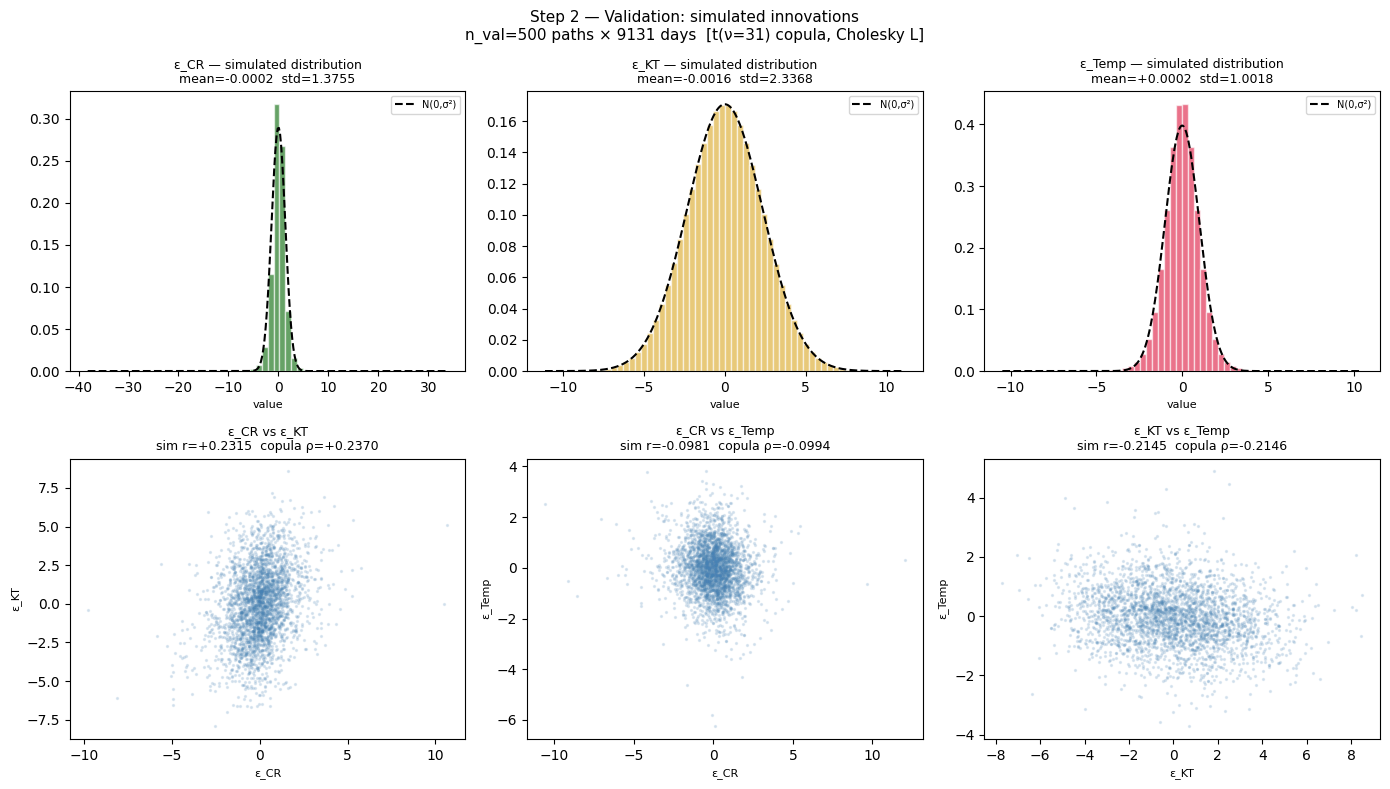

In [14]:

# ─────────────────────────────────────────────────────────────────────────────
# Compare simulated marginal distributions and pairwise correlations
# against the historical values from the covariance notebook.
# Validation runs on a random sample of paths to avoid memory issues.
 
print(f"\n── Step 2: Validation ───────────────────────────────────────────")
 
# ── 2A: marginal statistics ───────────────────────────────────────────────────
# sample 500 paths for validation
n_val    = min(500, N_SIM)
idx_val  = np.random.choice(N_SIM, n_val, replace=False)
eps_cr_v = eps_cr_all[idx_val].ravel()
eps_kt_v = eps_kt_all[idx_val].ravel()
eps_tp_v = eps_temp_all[idx_val].ravel()
 
# historical reference values from covariance notebook Step 2
hist_ref = {
    "eps_cr":   {"mean": 0.0,    "std": 1.0,        "kurt_approx": 6/(nu_g-4) if nu_g>4 else 99, "dist": f"skewed-t(nu={nu_g:.1f}, eta={eta_g:+.4f})"},
    "eps_kt":   {"mean": 0.0,    "std": sigma_kt,   "kurt_approx": 0.0},
    "eps_temp": {"mean": 0.0,    "std": sigma_temp, "kurt_approx": 0.0},
}
 
print(f"\n  Marginal statistics (simulated vs target):")
print(f"  {'Variable':<12}  {'sim mean':>10}  {'tgt mean':>10}  "
      f"{'sim std':>9}  {'tgt std':>9}  {'sim kurt':>9}")
print(f"  {'-'*12}  {'-'*10}  {'-'*10}  "
      f"{'-'*9}  {'-'*9}  {'-'*9}")
 
for label, col, vals in [
    ("eps_cr",   "eps_cr",   eps_cr_v),
    ("eps_kt",   "eps_kt",   eps_kt_v),
    ("eps_temp", "eps_temp", eps_tp_v),
]:
    ref = hist_ref[col]
    print(f"  {label:<12}  "
          f"{vals.mean():>10.5f}  {ref['mean']:>10.5f}  "
          f"{vals.std():>9.5f}  {ref['std']:>9.5f}  "
          f"{stats.kurtosis(vals):>9.3f}")
 
# ── 2B: pairwise correlations ─────────────────────────────────────────────────
sim_mat = np.column_stack([eps_cr_v, eps_kt_v, eps_tp_v])
corr_sim = np.corrcoef(sim_mat.T)
 
print(f"\n  Pairwise Pearson correlation (simulated vs fitted copula):")
pair_labels = ["CR–KT", "CR–Temp", "KT–Temp"]
pair_idx    = [(0,1),   (0,2),     (1,2)]
print(f"  {'Pair':<12}  {'Simulated':>10}  {'Copula':>10}  {'Δ':>8}")
print(f"  {'-'*12}  {'-'*10}  {'-'*10}  {'-'*8}")
for label, (i, j) in zip(pair_labels, pair_idx):
    r_sim = corr_sim[i, j]
    r_cop = corr_matrix[i, j]
    print(f"  {label:<12}  {r_sim:>10.4f}  {r_cop:>10.4f}  "
          f"{r_sim-r_cop:>+8.4f}")
 
# ── 2C: PIT uniformity check on sample ────────────────────────────────────────
print(f"\n  PIT uniformity check (KS test vs Uniform[0,1]):")
print(f"  {'Variable':<12}  {'U mean':>8}  {'U std':>8}  {'KS p':>8}  result")
print(f"  {'-'*12}  {'-'*8}  {'-'*8}  {'-'*8}  ------")
 
for label, vals, nu_v, scale_v, is_t in [
    ("eps_cr",   eps_cr_v,  nu_g, scale_unit_cr, True),
    ("eps_kt",   eps_kt_v,  0,     sigma_kt,   False),
    ("eps_temp", eps_tp_v,  nu_temp, scale_temp, True),   # ← nu_temp and scale_temp
]:
    if is_t:
        U = t_dist.cdf(vals / scale_v, df=nu_v)
    else:
        U = norm.cdf(vals, 0, scale_v)
    U = np.clip(U, 1e-6, 1-1e-6)
    ks_stat, ks_p = stats.kstest(U, "uniform")
    result = "✓ uniform" if ks_p > 0.05 else "✗ non-uniform"
    print(f"  {label:<12}  {U.mean():>8.4f}  {U.std():>8.4f}  "
          f"{ks_p:>8.4f}  {result}")
 
# ── 2D: validation plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
 
# row 1: marginal distributions
for j, (label, vals, color) in enumerate([
    ("ε_CR",   eps_cr_v, "darkgreen"),
    ("ε_KT",   eps_kt_v, "goldenrod"),
    ("ε_Temp", eps_tp_v, "crimson"),
]):
    ax = axes[0, j]
    ax.hist(vals, bins=60, density=True, color=color,
            alpha=0.6, edgecolor="white")
    x_g = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(x_g, stats.norm.pdf(x_g, 0, vals.std()),
            color="black", lw=1.5, ls="--", label="N(0,σ²)")
    ax.set_title(f"{label} — simulated distribution\n"
                 f"mean={vals.mean():+.4f}  std={vals.std():.4f}",
                 fontsize=9)
    ax.set_xlabel("value", fontsize=8)
    ax.legend(fontsize=7)
 
# row 2: scatter plots of key pairs
pair_plot = [
    ("ε_CR",   eps_cr_v, "ε_KT",   eps_kt_v, corr_matrix[0,1]),
    ("ε_CR",   eps_cr_v, "ε_Temp", eps_tp_v, corr_matrix[0,2]),
    ("ε_KT",   eps_kt_v, "ε_Temp", eps_tp_v, corr_matrix[1,2]),
]
for j, (xl, xv, yl, yv, rho_cop) in enumerate(pair_plot):
    ax = axes[1, j]
    # subsample for plot
    idx_p = np.random.choice(len(xv), min(3000, len(xv)), replace=False)
    ax.scatter(xv[idx_p], yv[idx_p], s=2, alpha=0.15, color="steelblue")
    r_s = np.corrcoef(xv, yv)[0, 1]
    ax.set_xlabel(xl, fontsize=8)
    ax.set_ylabel(yl, fontsize=8)
    ax.set_title(f"{xl} vs {yl}\n"
                 f"sim r={r_s:+.4f}  copula ρ={rho_cop:+.4f}",
                 fontsize=9)
 
plt.suptitle(f"Step 2 — Validation: simulated innovations\n"
             f"n_val={n_val} paths × {N_DAYS} days  "
             f"[t(ν={nu_copula}) copula, Cholesky L]",
             fontsize=11)
plt.tight_layout()
plt.show()


# Saving

In [15]:
# STEP 3 — Save to parquet
# ─────────────────────────────────────────────────────────────────────────────
# Long format: one row per (sim_id, date)
# Columns: sim_id, date, eps_cr, eps_kt, eps_temp
#
# Memory note: N_SIM × N_DAYS rows in long format can be large.
# We write in chunks by sim_id to avoid peak memory issues.
 
print(f"\n── Step 3: Save innovations ─────────────────────────────────────")
 
out_path   = data_sim / "mc_innovations.parquet"
CHUNK_SIZE = 500   # sim paths per write chunk
 
print(f"  Output path : {out_path}")
print(f"  Format      : long  (sim_id, date, eps_cr, eps_kt, eps_temp)")
print(f"  Writing {N_SIM} paths in chunks of {CHUNK_SIZE}...")
 
t_save = time.time()
chunks = []
 
for chunk_start in range(0, N_SIM, CHUNK_SIZE):
    chunk_end = min(chunk_start + CHUNK_SIZE, N_SIM)
    n_chunk   = chunk_end - chunk_start
 
    # tile dates for this chunk: (n_chunk × N_DAYS,)
    dates_rep = np.tile(dates_sim, n_chunk)
    sim_ids   = np.repeat(np.arange(chunk_start, chunk_end), N_DAYS)
 
    chunk_df = pd.DataFrame({
        "sim_id":   sim_ids.astype(np.int32),
        "date":     dates_rep,
        "eps_cr":   eps_cr_all[chunk_start:chunk_end].ravel(),
        "eps_kt":   eps_kt_all[chunk_start:chunk_end].ravel(),
        "eps_temp": eps_temp_all[chunk_start:chunk_end].ravel(),
    })
    chunks.append(chunk_df)
 
print(f"  Concatenating chunks...")
df_out = pd.concat(chunks, ignore_index=True)
 
# save
df_out.to_parquet(out_path, index=False, compression="snappy")
t_saved = time.time() - t_save
 
file_mb = out_path.stat().st_size / 1e6
print(f"  Saved in {t_saved:.1f}s")
print(f"  File size: {file_mb:.1f} MB")
print(f"  Rows     : {len(df_out):,}")
print(f"  Columns  : {list(df_out.columns)}")


── Step 3: Save innovations ─────────────────────────────────────
  Output path : ..\..\Data\Simulated\mc_innovations.parquet
  Format      : long  (sim_id, date, eps_cr, eps_kt, eps_temp)
  Writing 1000 paths in chunks of 500...
  Concatenating chunks...
  Saved in 3.3s
  File size: 175.5 MB
  Rows     : 9,131,000
  Columns  : ['sim_id', 'date', 'eps_cr', 'eps_kt', 'eps_temp']


In [16]:
# ── save simulation metadata ──────────────────────────────────────────────────
sim_metadata = {
    "random_seed":    RANDOM_SEED,
    "N_SIM":          N_SIM,
    "N_DAYS":         N_DAYS,
    "start_date":     START_DATE,
    "end_date":       END_DATE,
    "variable_cols":  VAR_COLS,
    "variable_labels":VAR_LABELS,
    "copula_type":    copula_params["copula_type"],
    "nu_copula":      nu_copula,
    "nu_g":           nu_g,
    "eta_g":          eta_g,
    "scale_unit_cr":  scale_unit_cr,
    "sigma_kt":       sigma_kt,
    "nu_temp":        nu_temp,     
    "scale_temp":     scale_temp,
    "sigma_temp":     sigma_temp,
    "corr_matrix":    corr_matrix.tolist(),
    "chol_matrix":    chol_matrix.tolist(),
    "output_file":    str(out_path),
    "file_size_mb":   round(file_mb, 2),
}
 
with open(data_sim / "mc_innovations_metadata.pkl", "wb") as f:
    pickle.dump(sim_metadata, f)
 
print(f"  Metadata saved: {data_sim / 'mc_innovations_metadata.pkl'}")

  Metadata saved: ..\..\Data\Simulated\mc_innovations_metadata.pkl
